In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from torchvision.io import decode_image
from torch.utils.data import Dataset
import os
import zipfile
from torchvision.transforms.v2 import functional as F
from torch.nn import functional as nnF

## 1. Dataset SIR2

Decompression depuis Drive puis extraction des 3 sous-datasets.

In [3]:
base = "/content/data/SIR2"

with zipfile.ZipFile("/content/drive/MyDrive/hanyang/SIR2.zip") as z:
    z.extractall(base)

inner = {
    "SolidObjectDataset.zip": "SolidObject",
    "Postcard Dataset.zip": "Postcard",
    "Wildscene.zip": "Wild",
}
for z, out in inner.items():
    with zipfile.ZipFile(os.path.join(base, z)) as zf:
        zf.extractall(os.path.join(base, out))
    print(f"{z} -> {out}/ OK")

SolidObjectDataset.zip -> SolidObject/ OK
Postcard Dataset.zip -> Postcard/ OK
Wildscene.zip -> Wild/ OK


Chaque scene = un dossier de 3 images : `r` (reflection / B), `m` (mixture / I), `g` (ground truth / T).

In [4]:
def det_role(str):
    if "r." in str or "-r" in str:
        return "r"
    elif "m." in str or "-m" in str:
        return "m"
    else:
        return "g"


def build_index(subset_root):
    """
    input: str
    output: list[dict]
    """
    dico = []
    for dirpath, dirnames, filenames in os.walk(subset_root):
        if len(filenames) == 3:
            if "jpg" in filenames[0][-3:] or "png" in filenames[0][-3:]:
                dico.append({det_role(i): os.path.join(dirpath, i) for i in filenames})

    return dico


index = build_index(base)
print(len(index), index[15])

500 {'m': '/content/data/SIR2/SolidObject/SolidObjectDataset/15/Focus/27/m.jpg', 'g': '/content/data/SIR2/SolidObject/SolidObjectDataset/15/Focus/27/g.jpg', 'r': '/content/data/SIR2/SolidObject/SolidObjectDataset/15/Focus/27/r.jpg'}


In [5]:
class SirDataset(Dataset):
    """
    Dataset SIR
    ds[i] -> [R, I, T]   (reflection, mixture, transmission), uint8 [3,400,536]
    """
    def __init__(self, base):
        self.index = build_index(base)
        self.crop = v2.CenterCrop((400, 536))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        dic_i = self.index[i]
        r, m, g = decode_image(dic_i["r"]), decode_image(dic_i['m']), decode_image(dic_i['g'])
        return [self.crop(r), self.crop(m), self.crop(g)]


ds = SirDataset(base)
print(len(ds), ds[15][0].shape, ds[15][0].dtype)

500 torch.Size([3, 400, 536]) torch.uint8


**RAPPEL** :  
I &nbsp;&nbsp;&nbsp;&nbsp;=&nbsp;&nbsp;&nbsp;&nbsp; T &nbsp;&nbsp;&nbsp;&nbsp;+&nbsp;&nbsp;&nbsp;&nbsp; B  
ds[i][1] &nbsp;&nbsp; ds[i][2] &nbsp;&nbsp; ds[i][0]

(valable en **[0,1]**, pas en [-1,1] : en [-1,1] la relation devient `I = T + B + 1`)

In [6]:
transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),   # -> [-1, 1]
])

## 2. VAE FLUX

In [7]:
DTYPE = torch.float32

from diffusers import AutoencoderKL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    subfolder="vae",
    torch_dtype=DTYPE
).to(device)
print(device, vae.num_parameters())

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/821 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  168MB            

vae/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Some weights of the model checkpoint at black-forest-labs/FLUX.2-klein-4B were not used when initializing AutoencoderKL: 
 ['bn.num_batches_tracked, bn.running_mean, bn.running_var']


cuda 84046115


## 3. Helpers

### Conversions 

In [8]:
to01  = lambda t: (t / 2 + 0.5).clamp(0, 1)   # [-1,1] -> [0,1] (clampe)
to01r = lambda t: (t / 2 + 0.5)              # idem sans clamp: pour visualiser des residus


def plot_decoded(x):
    """x dans [-1,1], shape [B,3,H,W]"""
    img = x[0]                                          # [3, H, W]
    img = (img / 2 + 0.5).clamp(0, 1)                   # [-1,1] -> [0,1]
    img = img.permute(1, 2, 0).float().cpu().numpy()    # HWC
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def plot_decoded_01(x):
    """x deja dans [0,1], shape [B,3,H,W]"""
    img = x[0]                                          # [3, H, W]
    img = img.permute(1, 2, 0).float().cpu().numpy()    # HWC
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Access to a triplet

In [9]:
def i_t_b(i, to01=True):
    """
    Renvoie I, T, R du sample i, sur device, shape [1,3,H,W].
    to01=True  -> [0, 1]
    to01=False -> [-1, 1]  (espace natif du VAE)
    """
    r = (lambda x: x / 2 + 0.5) if to01 else (lambda x: x)
    I, T, R = transforms(ds[i][1]), transforms(ds[i][2]), transforms(ds[i][0])
    I, T, R = I.unsqueeze(0), T.unsqueeze(0), R.unsqueeze(0)
    I, T, R = r(I.to(device, dtype=DTYPE)), r(T.to(device, dtype=DTYPE)), r(R.to(device, dtype=DTYPE))
    return I, T, R


def enc(x):
    """encode -> latent (mode de la posterior)"""
    with torch.no_grad():
        return vae.encode(x).latent_dist.mode()


def dec(z):
    with torch.no_grad():
        return vae.decode(z).sample

### Metrics

In [10]:
def psnr(pred, target, max_val=1.0):
    pred, target = pred.float(), target.float()
    mse = torch.mean((pred - target) ** 2)
    return 10 * torch.log10(max_val**2 / mse)


def cosine(a, b):
    """
    input: torch.tensor, torch.tensor
    output: float
    """
    a = a.flatten()
    b = b.flatten()
    return torch.dot(a, b) / (torch.norm(a) * torch.norm(b))

### Additivite  I = T + beta*B

In [11]:
def betaf(a, b, c):
    """beta = <I-T, B> / <B,B>, par canal -> (1,3,1,1)"""
    return (((a - b) * c).sum((2, 3)) / (c * c).sum((2, 3))).unsqueeze(-1).unsqueeze(-1)


def tb_resf(a, b, c):
    return ((a - (b + c)) ** 2).mean().item()


def tbetab_resf(a, b, c):
    beta = betaf(a, b, c)
    return ((a - (b + beta * c)) ** 2).mean().item()


def srgb_to_linear(x):
    lo = x / 12.92
    hi = ((x.clamp_min(0.04045) + 0.055) / 1.055) ** 2.2
    return torch.where(x <= 0.04045, lo, hi)

### Gradients d'image

In [12]:
import torch.nn.functional as nnF


def image_gradients(x, technique='sobel'):
    """x: (B,C,H,W) -> gx, gy de meme shape (noyau normalise)"""
    C = x.shape[1]
    if technique == 'sobel':
        kx = torch.tensor([[-1., 0., 1.],
                           [-2., 0., 2.],
                           [-1., 0., 1.]], device=x.device, dtype=x.dtype) / 8
    elif technique == 'scharr':
        kx = torch.tensor([[-3., 0., 3.],
                           [-10., 0., 10.],
                           [-3., 0., 3.]], device=x.device, dtype=x.dtype) / 32
    elif technique == 'prewitt':
        kx = torch.tensor([[-1., 0., 1.],
                           [-1., 0., 1.],
                           [-1., 0., 1.]], device=x.device, dtype=x.dtype) / 6
    kx = kx.expand(C, 1, 3, 3).contiguous()
    ky = kx.transpose(-2, -1).contiguous()
    xp = nnF.pad(x, (1, 1, 1, 1), mode='replicate')
    return nnF.conv2d(xp, kx, groups=C), nnF.conv2d(xp, ky, groups=C)


def gradient_mag(grad_x, grad_y):
    mag = torch.sqrt(grad_x**2 + grad_y**2)
    return mag / mag.max()


def gradient_dir(grad_x, grad_y):
    return torch.atan2(grad_y, grad_x)

## 4. Sanity check

torch.Size([1, 3, 400, 536]) 0.13725489377975464 1.0


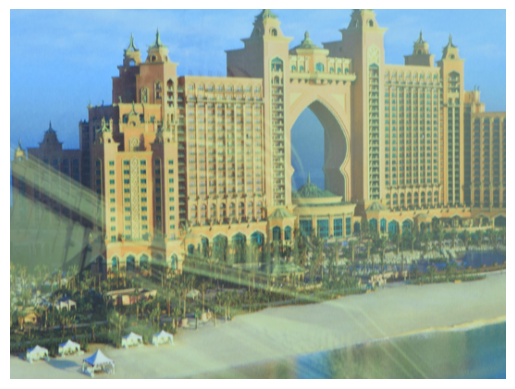

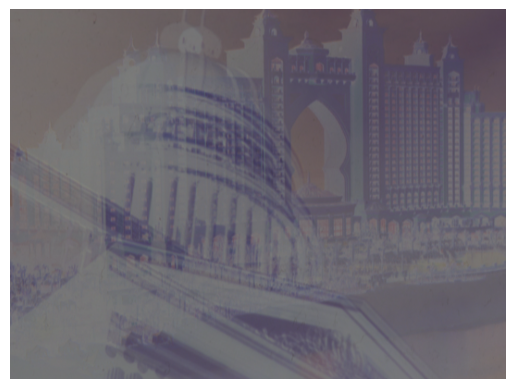

In [13]:
i = 200
I, T, B = i_t_b(i, to01=True)
print(I.shape, I.min().item(), I.max().item())
plot_decoded_01(I)
plot_decoded_01(to01r(I - (T + B)))   

### Wavelet Color Correction 

In [ ]:
kernel_vals = [
    [0.0625, 0.125, 0.0625],
    [0.125, 0.25, 0.125],
    [0.0625, 0.125, 0.0625],
]
kernel = torch.tensor(kernel_vals, dtype=I.dtype, device=I.device).unsqueeze(0).unsqueeze(0)
kernel = kernel.repeat(1, 3, 1, 1)

# result = nnF.conv2d(I, kernel)

tensor([[[[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]],

         [[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]],

         [[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]]]], device='cuda:0')


#### Ways to smooth the image?

In [30]:
def smooth(I, r, label='blur'):
    if label=="blur":
        kernel_vals = [
        [0.0625, 0.125, 0.0625],
        [0.125, 0.25, 0.125],
        [0.0625, 0.125, 0.0625],
    ]
    C = I.shape[1]
    kernel = torch.tensor(kernel_vals, dtype=I.dtype, device=I.device).unsqueeze(0).unsqueeze(0)
    kernel = kernel.repeat(C,1,1,1)
    # here we got r because C=3!!!!!!
    I = nnF.pad(I, (r, r, r, r), mode='replicate')
    return nnF.conv2d(I, kernel, groups=C, dilation=r)
smooth(I,8).shape, I.shape

(torch.Size([1, 3, 400, 536]), torch.Size([1, 3, 400, 536]))

In [ ]:
torch.cuda

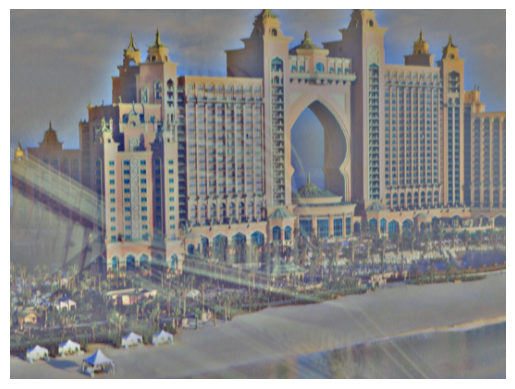

In [52]:
def wavelet_corr(I, lvls):
    """
    I: image tensor (B, C, H, W)
    r = radius of dilatation ? 
    lvls = levels: how deep we go in the process of smoothing
    l means the lowest frequency of the process.
    We have a telescopic sum
    """
    curr = I
    for i in range(lvls):
        curr = smooth(curr, 2**i, label='blur')
    return I - curr
res = wavelet_corr(I, 5)
res = to01r(res / max(abs(torch.amax(res)), abs(torch.amin(res))))
plot_decoded_01(res)

    

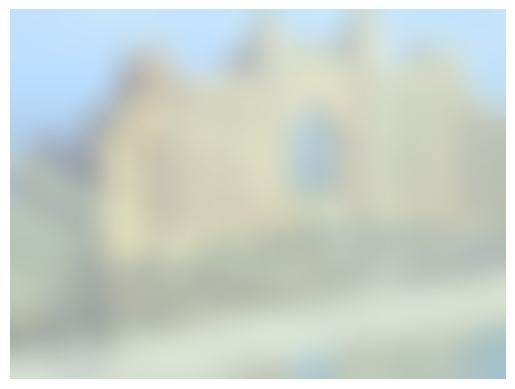

In [53]:
res = I - res 
res = to01r(res / max(abs(torch.amax(res)), abs(torch.amin(res))))
plot_decoded(res)